In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import ne_chunk, pos_tag
from nltk.tree import Tree
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Codeprentice\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Codeprentice\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Codeprentice\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Codeprentice\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\Codeprentice\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\Codeprentice\AppData\Roaming\nltk_data...


True

In [59]:
df = pd.read_csv('Datos.csv')
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9595 entries, 0 to 9594
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Course Title         9595 non-null   object 
 1   Rating               8156 non-null   float64
 2   Level                8330 non-null   object 
 3   Duration             9333 non-null   object 
 4   Schedule             8912 non-null   object 
 5   Review               8152 non-null   object 
 6   What you will learn  4984 non-null   object 
 7   Skill gain           9595 non-null   object 
 8   Modules              9595 non-null   object 
 9   Instructor           9595 non-null   object 
 10  Offered By           9595 non-null   object 
 11  Keyword              9595 non-null   object 
 12  Course Url           9595 non-null   object 
dtypes: float64(1), object(12)
memory usage: 974.6+ KB


,Rating
count,8156.000000
mean,4.651533
std,0.240674
min,1.500000
25%,4.600000
50%,4.700000
75%,4.800000
max,5.000000


In [85]:
df['Duration'] = df['Duration'].fillna('0 hours')
df['Level'] = df['Level'].fillna('Unknown Level')
df['Review'] = df['Review'].fillna('0 reviews')
df['Rating'] = df['Rating'].fillna(0)
df = df.fillna(0)

In [46]:
print(df.columns.tolist())

['Course Title', 'Rating', 'Level', 'Duration', 'Schedule', 'Review', 'What you will learn', 'Skill gain', 'Modules', 'Instructor', 'Offered By', 'Keyword', 'Course Url']


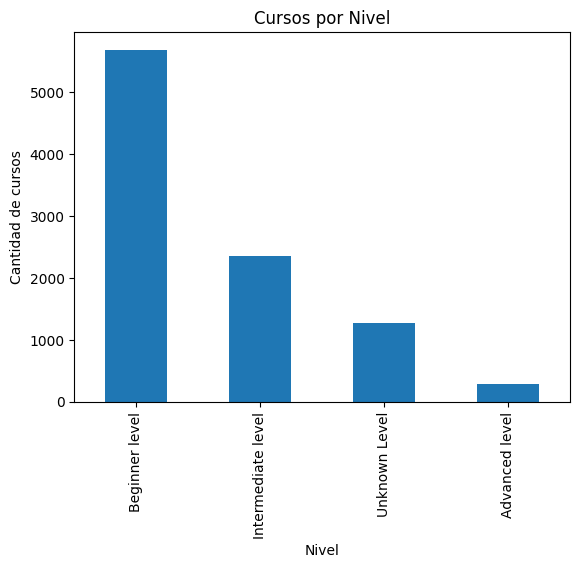

In [47]:
# a) Gráfica de barras por nivel del curso
df['Level'].value_counts().plot(kind='bar', title='Cursos por Nivel')
plt.xlabel('Nivel')
plt.ylabel('Cantidad de cursos')
plt.show()

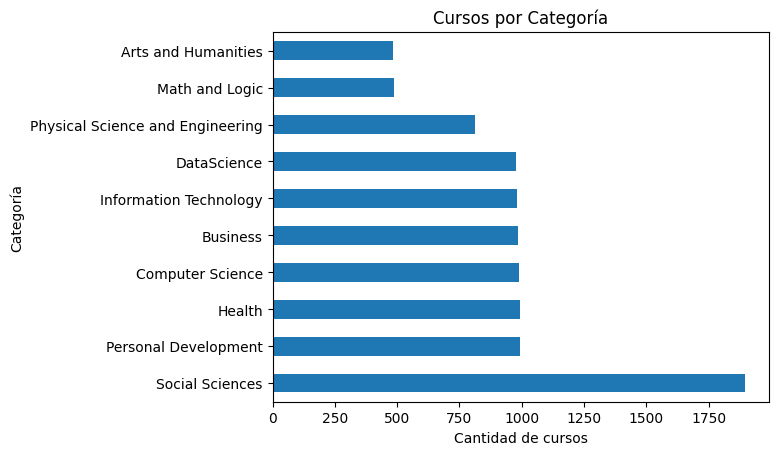

In [60]:
# b) Gráfica de barras horizontal por categoría 
df['Keyword'].value_counts().head(10).plot(kind='barh', title='Cursos por Categoría')
plt.xlabel('Cantidad de cursos')
plt.ylabel('Categoría')
plt.show()

In [ ]:
import re

def parse_duration(duration_str):
    if pd.isna(duration_str):
        return None

    duration_str = str(duration_str).lower()

    months_match = re.search(r'(\d+(\.\d+)?)\s*months?.*?(\d+(\.\d+)?)\s*hours', duration_str)
    if months_match:
        months = float(months_match.group(1))
        hours_per_week = float(months_match.group(3))
        return months * 4 * hours_per_week

    hours_match = re.search(r'(\d+(\.\d+)?)\s*hours?', duration_str)
    if hours_match:
        return float(hours_match.group(1))

    # Handle word-based numbers
    word_to_number = {
        'one': 1,
        'two': 2,
        'three': 3,
        'four': 4,
        'five': 5
    }

    for word, value in word_to_number.items():
        if word in duration_str and 'hour' in duration_str:
            return float(value)

    return None


In [89]:
df['Duration_numeric'] = df['Duration'].apply(parse_duration)
print(df['Duration_numeric'].isna().sum(), "missing Duration values after fix")


0 missing Duration values after fix


In [90]:
df['Review_numeric'] = df['Review'].astype(str).str.replace(',', '', regex=False).str.extract(r'(\d+)')[0].astype(float)

In [81]:
df[df['Duration_numeric'].isna()]['Duration'].value_counts().head(20)

Series([], Name: count, dtype: int64)

In [86]:
df[df['Review_numeric'].isna()]['Review'].value_counts().head(20)


Series([], Name: count, dtype: int64)

In [91]:
print(df['Duration_numeric'].isna().sum(), "missing Duration values")
print(df['Review_numeric'].isna().sum(), "missing Review values")

0 missing Duration values
0 missing Review values


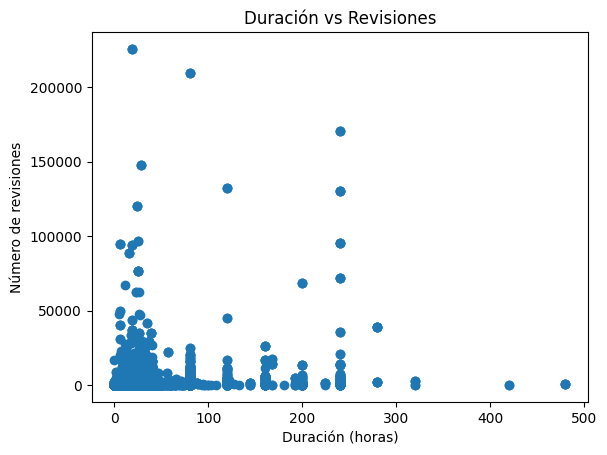

In [92]:
# c) Gráfico de dispersión duración vs número de revisiones
plt.scatter(df['Duration_numeric'], df['Review_numeric'])
plt.xlabel('Duración (horas)')
plt.ylabel('Número de revisiones')
plt.title('Duración vs Revisiones')
plt.show()

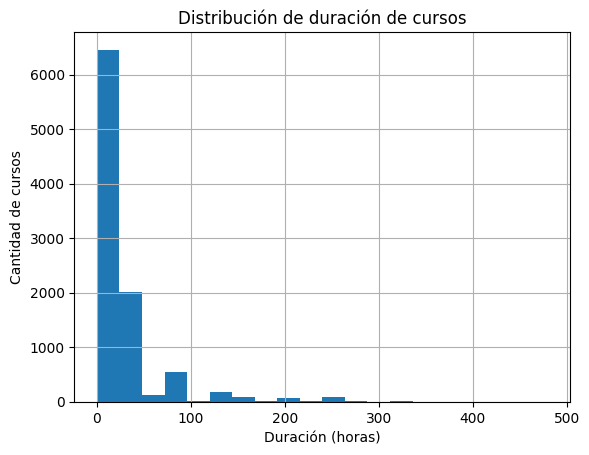

In [98]:
# d) Histograma de duración de cursos
df['Duration_numeric'].dropna().hist(bins=20)
plt.title('Distribución de duración de cursos')
plt.xlabel('Duración (horas)')
plt.ylabel('Cantidad de cursos')
plt.show()

In [97]:
df[['Course Title', 'Duration', 'Duration_numeric']].head(50)


,Course Title,Duration,Duration_numeric
0,Fashion as Design,20 hours (approximately),20.0
1,Modern American Poetry,Approx. 34 hours to complete,34.0
2,Pixel Art for Video Games,9 hours (approximately),9.0
3,Distribución digital de la música independiente,Approx. 8 hours to complete,8.0
4,The Blues: Understanding and Performing an Ame...,Approx. 11 hours to complete,11.0
5,So You Think You Know Tango?,Approx. 5 hours to complete,5.0
6,The Politics of Skepticism,Approx. 13 hours to complete,13.0
7,Становлення сучасної України,Approx. 23 hours to complete,23.0
8,Exploring Beethoven's Piano Sonatas Part 4,Approx. 5 hours to complete,5.0
9,悖论：思维的魔方,Approx. 44 hours to complete,44.0


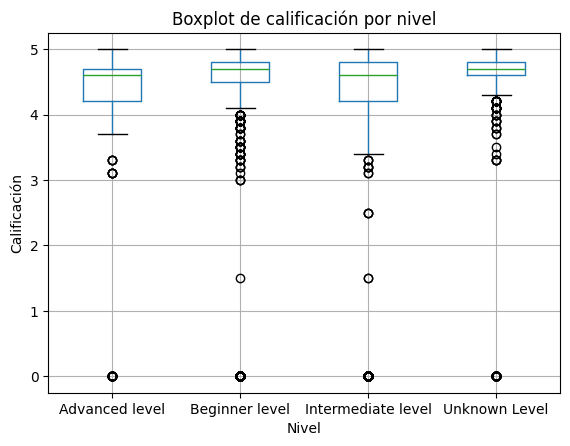

In [99]:
# e) Boxplot de calificación por nivel
df.boxplot(column='Rating', by='Level')
plt.title('Boxplot de calificación por nivel')
plt.suptitle('')
plt.xlabel('Nivel')
plt.ylabel('Calificación')
plt.show()

In [100]:
# Calificación promedio por curso
df.groupby('Course Title')['Rating'].mean()

Course Title
 Assisting Public Sector Decision Makers With Policy Analysis                                                          4.8
 Atención prehospitalaria del ictus agudo y selección de pacientes para tratamiento endovascular con la escala RACE    4.9
 Build a social media presence for your business using Canva                                                           4.7
 Build social awareness content for Twitter with Canva                                                                 0.0
 Comercio, Inmigración y Tipos de Cambio en un Mundo Globalizado                                                       4.9
                                                                                                                      ... 
현대 로봇공학, 강좌 2: 로봇 기구학                                                                                                  0.0
현대 로봇공학, 강좌 3: 로봇 동역학                                                                                                  0.0
현대 

In [101]:
# Curso con mayor y menor rating
df[df['Rating'] == df['Rating'].max()]

,Course Title,Rating,Level,Duration,Schedule,Review,What you will learn,Skill gain,Modules,Instructor,Offered By,Keyword,Course Url,Duration_numeric,Review_numeric
166,Songwriting: Writing the Music,5.0,Intermediate level,11 hours (approximately),Flexible schedule,43 reviews,0,"['Music', 'Melodic Hooks', 'Songwriting', 'Har...","['Welcome to Songwriting: Writing the Music', ...",['Scarlet Keys'],['Berklee'],Arts and Humanities,https://www.coursera.org/learn/songwriting-wri...,11.0,43.0
356,Western Religions & Ecology,5.0,Beginner level,Approx. 18 hours to complete,Flexible schedule,13 reviews,0,"['Philosophy', 'conservation', 'Religion', 'Ec...","['MODULE 1: Course Introduction', 'MODULE 2: I...","['Mary Evelyn Tucker', 'John Grim']",['Yale University'],Arts and Humanities,https://www.coursera.org/learn/western-religio...,18.0,13.0
362,El Holocausto: el abismo de la humanidad,5.0,Beginner level,Approx. 21 hours to complete,Flexible schedule,28 reviews,Ahondaremos en la vida de los judíos entreguer...,[],['La vida judía antes del Holocausto y el asce...,['Sandra Rosenfeld Katz'],['Yad Vashem '],Arts and Humanities,https://www.coursera.org/learn/el-holocausto,21.0,28.0
364,莊子─人情 (Zhuangzi─Between People),5.0,Beginner level,Approx. 19 hours to complete,Flexible schedule,45 reviews,0,[],"['〈人間世〉〈一〉', '〈人間世〉〈二〉', '〈人間世〉〈三〉', '〈人間世〉〈四〉...",['蔡璧名'],['National Taiwan University'],Arts and Humanities,https://www.coursera.org/learn/zhuangzi2,19.0,45.0
376,Exploring Beethoven’s Piano Sonatas Part 2,5.0,Beginner level,Approx. 8 hours to complete,Flexible schedule,161 reviews,0,[],"['Welcome to Class!', 'Op. 2, No. 3', 'Op. 13,...",['Jonathan Biss'],['Curtis Institute of Music'],Arts and Humanities,https://www.coursera.org/learn/exploring-beeth...,8.0,161.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9132,Claves para la igualdad de género Specialization,5.0,Beginner level,1 months at 10 hours a week,Flexible schedule,6 reviews,0,[],['Conceptos básicos para la igualdad de género...,"['Iliana Noemí Palafox Luevano', 'Lourdes Enrí...",['Universidad Nacional Autónoma de México'],Social Sciences,https://www.coursera.org/specializations/clave...,40.0,6.0
9287,Tecnologías para la Innovación Educativa,5.0,Beginner level,Approx. 50 hours to complete,Flexible schedule,10 reviews,Analizar tendencias tecnológicas que pueden te...,[],['Módulo 1: Tendencias en tecnologías para la ...,['Eder Estrada Villalba'],['Tecnológico de Monterrey'],Social Sciences,https://www.coursera.org/learn/tecnologas-para...,50.0,10.0
9377,Escola 4.0 Educação e Cultura Maker no Context...,5.0,Beginner level,Approx. 10 hours to complete,Flexible schedule,48 reviews,0,['Aplicar metodologias ativas de ensino.'],"['Bem Vindos!', 'Aspéctos pedagógicos', 'O Mov...",['Fabiano Fruett'],['Universidade Estadual de Campinas'],Social Sciences,https://www.coursera.org/learn/escola4pontozero,10.0,48.0
9533,Activity Design with PhET Simulations for STEM...,5.0,Intermediate level,13 hours (approximately),Flexible schedule,27 reviews,Assess equity in an Activity Sheet.Develop str...,"['Teaching', 'Simulation', 'Lesson Plan']",['Module 1: Introduction: Students Interacting...,"['Zachariah Mbasu', 'Rebecca Vieyra']",['University of Colorado Boulder'],Social Sciences,https://www.coursera.org/learn/activity-design...,13.0,27.0


In [102]:
df[df['Rating'] == df['Rating'].min()]

,Course Title,Rating,Level,Duration,Schedule,Review,What you will learn,Skill gain,Modules,Instructor,Offered By,Keyword,Course Url,Duration_numeric,Review_numeric
3,Distribución digital de la música independiente,0.0,Beginner level,Approx. 8 hours to complete,Flexible schedule,0 reviews,0,[],"['Semana 1', 'Semana 2', 'Semana 3', 'Semana 4']",['Eduardo de la Vara Brown.'],['SAE Institute México'],Arts and Humanities,https://www.coursera.org/learn/distribucion-di...,8.0,0.0
7,Становлення сучасної України,0.0,Beginner level,Approx. 23 hours to complete,Flexible schedule,0 reviews,0,[],['Становлення сучасної України'],['Timothy Snyder'],['Yale University'],Arts and Humanities,https://www.coursera.org/learn/the-making-of-m...,23.0,0.0
16,Create your UX portfolio with Adobe Portfolio,0.0,Beginner level,0 hours,0,0 reviews,In this project you will learn how to create a...,"['Share Content', 'Search Engine Optimization ...",['Learn step-by-step'],['Nicole Alvelo'],['Coursera Project Network'],Arts and Humanities,https://www.coursera.org/projects/create-your-...,0.0,0.0
20,Cultura Maya en Yucatán,0.0,Beginner level,Approx. 14 hours to complete,Flexible schedule,0 reviews,Conocerás los aspectos fundamentales de la Cul...,[],"['Inicia aquí', 'Módulo 1: Introducción a la C...","['Alejandro Esteban Fitzmaurice Cahluni', 'Jor...",['Universidades Anáhuac'],Arts and Humanities,https://www.coursera.org/learn/cultura-maya-en...,14.0,0.0
22,"Herencia negra, aplicación de ritmos afroperuanos",0.0,Beginner level,Approx. 16 hours to complete,Flexible schedule,0 reviews,0,"['Musical Notation', 'Musical Composition']","['Bienvenida al curso', 'Panorama de la cultur...",['Javier Lazo Figueroa'],['Pontificia Universidad Católica del Perú'],Arts and Humanities,https://www.coursera.org/learn/aplicacion-ritm...,16.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9582,Housing Justice: A View from Indian Cities,0.0,Beginner level,Approx. 17 hours to complete,Flexible schedule,0 reviews,0,[],"['Introduction to the Course', 'Framing Module...","['Gautam Bhan', 'Swastik Harish']",['Indian Institute for Human Settlements'],Social Sciences,https://www.coursera.org/learn/housing-justice...,17.0,0.0
9584,R Programming and Tidyverse Capstone Project,0.0,Beginner level,9 hours (approximately),Flexible schedule,0 reviews,"Utilize R programming to import, clean, and ti...","['Data Analysis', 'Communication', 'Data Manip...","['COVID-19 Data Analysis: Getting Started', 'C...",['Jane Wall'],['University of Colorado Boulder'],Social Sciences,https://www.coursera.org/learn/r-programming-t...,9.0,0.0
9586,Using Microsoft PowerPoint to Create a Choice ...,0.0,Beginner level,1 hour,0,0 reviews,Learn about choice boards and their use within...,"['online tools', 'classroom learning', 'engagi...",['Learn step-by-step'],['Rachel Lindsay'],['Coursera Project Network'],Social Sciences,https://www.coursera.org/projects/using-micros...,1.0,0.0
9587,"India-US Relations: Geopolitics, Culture, and ...",0.0,Beginner level,33 hours (approximately),Flexible schedule,0 reviews,Describe the scope and breadth of India-US rel...,"['analytical thinking', 'Cultural Awareness', ...","['American Culture', 'India-US Strategic Relat...",['Dr. Rajdeep Pakanati'],['O.P. Jindal Global University'],Social Sciences,https://www.coursera.org/learn/india-us-relati...,33.0,0.0


In [105]:
min_rating = df[df['Rating'] > 0]['Rating'].min()
df[df['Rating'] == min_rating]

,Course Title,Rating,Level,Duration,Schedule,Review,What you will learn,Skill gain,Modules,Instructor,Offered By,Keyword,Course Url,Duration_numeric,Review_numeric
1278,Excel for Beginners: Beginner Functions,1.5,Beginner level,0 hours,0,18 reviews,Summarize raw data with functions like SUM and...,"['Spreadsheet', 'Microsoft Excel']",['Learn step-by-step'],['Edward Falzon '],['Coursera Project Network'],Business,https://www.coursera.org/projects/excel-for-be...,0.0,18.0
5151,Build a computer vision app with Azure Cogniti...,1.5,Intermediate level,0 hours,0,129 reviews,Create a Computer Vision Cognitive Services re...,"['Artificial Intelligence (AI)', 'Software Dev...",['Learn step-by-step'],['Catalin Popa'],['Microsoft'],Information Technology,https://www.coursera.org/projects/build-a-comp...,0.0,129.0
5369,Build automated speech systems with Azure Cogn...,1.5,Intermediate level,0 hours,0,0 reviews,Create a Speech Cognitive Services resource us...,"['Artificial Intelligence (AI)', 'Software Dev...",['Learn step-by-step'],['Catalin Popa'],['Microsoft'],Information Technology,https://www.coursera.org/projects/build-automa...,0.0,0.0


In [106]:
# Porcentaje de cursos con horario flexible (según 'Schedule')
df['Schedule'].value_counts(normalize=True) * 100

Schedule
Flexible schedule    92.881709
0                     7.118291
Name: proportion, dtype: float64

### Análisis de estadísticas

- **Calificaciones promedio por curso:** Se calcularon utilizando `groupby`. Esto permite observar tendencias de valoración general y resalta los cursos más consistentes en calidad percibida.

- **Curso(s) con mayor rating (5.0):** *"Songwriting: Writing the Music"*, *"Western Religions & Ecology"*, entre otros. Estos cursos suelen destacar por su contenido bien estructurado, claridad, e instructores reconocidos

- **Curso con menor rating (excluyendo los de 0.0):** El curso *"Excel for Beginners: Beginner Functions"* tiene una calificación mínima de 1.5 (excluyendo los no calificados). Esto puede reflejar expectativas no cumplidas, problemas técnicos o baja calidad percibida

- **Cursos con rating 0.0:** Muchos cursos aún no han sido calificados (rating de 0), lo cual es importante distinguir al interpretar resultados.

- **Porcentaje de cursos con horario flexible:** Un **92.88%** de los cursos ofrecen modalidad flexible, lo cual indica una fuerte orientación hacia accesibilidad para estudiantes con distintas disponibilidades de tiempo. Solo un **7.12%** tiene otro tipo de programación (probablemente fija o no especificada).


In [107]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Codeprentice\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [125]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk import pos_tag, ne_chunk
from nltk.tree import Tree
from collections import Counter

# Descargar recursos necesarios
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')

# Leer archivo
with open("Coursera Comments.txt", "r", encoding="utf-8") as f:
    text = f.read()

# Tokenización
tokens = word_tokenize(text.lower(), preserve_line=True)
tokens = [word for word in tokens if word.isalpha()]

# Stopwords (en español)
filtered = [word for word in tokens if word not in stopwords.words('spanish')]

# Lematización y stemming
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
lemmas = [lemmatizer.lemmatize(word) for word in filtered]
stems = [stemmer.stem(word) for word in filtered]

# Frecuencia de palabras
freq = Counter(filtered)
print("Top 10 palabras más frecuentes:")
print(freq.most_common(10))

# Reconocimiento de entidades nombradas (aunque el texto está en español)
print("\nPosibles entidades (nombres propios):")
tagged = pos_tag(tokens)
for word, tag in tagged:
    if tag in ['NNP', 'NNPS']:
        print(word)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Codeprentice\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Codeprentice\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Codeprentice\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Codeprentice\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\Codeprentice\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\Codeprentice\AppData\Roaming\nltk_data...


Top 10 palabras más frecuentes:
[('semana', 1555), ('curso', 1048), ('dudas', 761), ('ta', 750), ('participantes', 738), ('portafolio', 720), ('si', 640), ('foros', 462), ('compañeros', 431), ('evaluación', 399)]

Posibles entidades (nombres propios):
único
y
y
ésta
xd
xd
y
última
x
x
xd
xd
y
última
x
x
única
école
école
ámbito
quezada
karlozqzada
única
éxito
líber
multimedia
él
x
útil
éxito
único
saber
quezada
ya
éstos
ésto
ánimo
saber
último
y
ámbito
miguelina
y
y
saber
saber
únicamente
katerina
éstos
única
ética
máquina
y
y
éxito
haber
zamora
ámbito
ánimo
ésto
y
ámbito
útil
útil
quezada
haber
índice
saber
ánimos
ánimos
único
és
ya
saber
único
único
x
mariana
y
saber
él
área
deber
última
saber
único
únicamente
saber
ésta
haber
ética
saber
última
últimos
katerina
éxito
único
saber
ética
saber
único
y
ánimo
único
él
saber
última
última
última
éxito
última
útil
última
área
útil
área
haber
últimos
quezada
la
ámbito
éxito
éxitos
última
éxito
útil
ímpetu
último
último
última
éxito
única
ha

In [126]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

sentimientos = sia.polarity_scores(text)
print(sentimientos)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Codeprentice\AppData\Roaming\nltk_data...


{'neg': 0.035, 'neu': 0.954, 'pos': 0.011, 'compound': -1.0}


### Análisis NLP del archivo Coursera Comments.txt

- **Tokenización:** Se dividió el texto en palabras individuales utilizando `word_tokenize` de NLTK.

- **Eliminación de stopwords:** Se eliminaron palabras comunes del español usando el conjunto `stopwords.words('spanish')`.

- **Lematización y Stemming:** Se aplicaron técnicas para reducir las palabras a su forma base. Se utilizó `WordNetLemmatizer` para la lematización y `PorterStemmer` para el stemming.

- **Frecuencia de palabras:** Se generó un conteo de las palabras más frecuentes, permitiendo identificar temas recurrentes. Las palabras más comunes incluyen: `semana`, `curso`, `dudas`, `participantes`, entre otras.

- **Reconocimiento de entidades nombradas:** Dado que `ne_chunk()` no está funcionando por falta de recursos internos en NLTK, se extrajeron nombres propios (`NNP`, `NNPS`) usando `pos_tag` como alternativa para detectar posibles entidades.

- **Análisis de sentimientos:** Se utilizó `SentimentIntensityAnalyzer` de NLTK para obtener una aproximación del tono general del archivo.  
  Los resultados fueron:
  
  - **Negativo:** 3.5%  
  - **Neutral:** 95.4%  
  - **Positivo:** 1.1%  
  - **Índice compuesto:** -1.0  

  Esto indica que el tono general del texto parece tener una **carga ligeramente negativa**
